# Importing the files used and data from Seine Aval (SAV)

In [22]:
%load_ext autoreload
%autoreload 2
    
from sarima import *
from preprocessing import SAV_preprocessing

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
df_sav = SAV_preprocessing()

# Construction of the Training Set and the Test Set
begin_test_index = df_sav.index.get_loc("2023-12-07 20:00:00")

df_train = df_sav.iloc[begin_test_index - 96*10 : begin_test_index]
df_train.index = pd.DatetimeIndex(df_train.index.values, freq = df_train.index.inferred_freq)

df_test_1j = df_sav.iloc[begin_test_index : begin_test_index + 96]
df_test_1j.index = pd.DatetimeIndex(df_test_1j.index.values, freq = df_test_1j.index.inferred_freq)

# Model Identification
## Periodogram test to confirm the seasonality observed graphically

In [13]:
df_periods = pd.DataFrame(index = ["Période 1", "Période 2", "Période 3", "Période 4", "Période 5", "Période 6", "Période 7", "Période 8", "Période 9", "Période 10"])

for compteur in range(len(df_train.columns.drop("Total flow"))):
    freq, spec = periodogram(df_train[df_train.columns[compteur]])
    argmax = np.argsort(spec)[::-1][:10]
    df_periods[df_train.columns[compteur]] = 1 / freq[argmax]

df_periods

,Conductivity SAV,pH SAV,Temperature SAV,TSS SAV
Période 1,960.000000,96.000000,960.000000,137.142857
Période 2,320.000000,960.000000,320.000000,960.000000
Période 3,480.000000,48.000000,240.000000,192.000000
Période 4,240.000000,240.000000,480.000000,96.000000
Période 5,137.142857,68.571429,96.000000,240.000000
Période 6,160.000000,32.000000,106.666667,160.000000
Période 7,80.000000,160.000000,48.000000,40.000000
Période 8,106.666667,120.000000,80.000000,320.000000
Période 9,120.000000,73.846154,160.000000,56.470588
Période 10,64.000000,60.000000,137.142857,80.000000


## Stationarity tests
Since $s=96$ is taken for all variables, the tests are conducted directly on the series differenced $96$ times.

In [25]:
# The Augmented Dickey–Fuller (ADF) test
adf_test(df_train.drop(columns="Total flow").diff(96).dropna())

Conductivity SAV
Augmented Dickey-Fuller Test Results:
ADF Test Statistic   -2.309047
P-Value               0.169067
dtype: float64
Is the time series stationary?  False
---------------------------------------------------------
pH SAV
Augmented Dickey-Fuller Test Results:
ADF Test Statistic   -5.541476
P-Value               0.000002
dtype: float64
Is the time series stationary?  True
---------------------------------------------------------
Temperature SAV
Augmented Dickey-Fuller Test Results:
ADF Test Statistic   -2.728637
P-Value               0.069213
dtype: float64
Is the time series stationary?  False
---------------------------------------------------------
TSS SAV
Augmented Dickey-Fuller Test Results:
ADF Test Statistic   -3.912303
P-Value               0.001946
dtype: float64
Is the time series stationary?  True
---------------------------------------------------------


In [27]:
# Kwiatkowski–Phillips–Schmidt–Shin (KPSS) test
kpss_test(df_train.drop(columns="Total flow").diff(96).dropna())

KPSS Statistic: 0.7601368065606083
p-value: 0.01
num lags: 18
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The Conductivity SAV series is not stationary
---------------------------------------------------------
KPSS Statistic: 0.27517189065502295
p-value: 0.1
num lags: 18
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The pH SAV series is stationary
---------------------------------------------------------
KPSS Statistic: 0.4951937403595305
p-value: 0.04274915757668232
num lags: 18
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The Temperature SAV series is not stationary
---------------------------------------------------------
KPSS Statistic: 0.1736427823787747
p-value: 0.1
num lags: 18
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The TSS SAV series is stationary
---------------------------------------------------------


**Another stationarity test for the series that were not stationary : The first‑order difference of the series differenced 96 times.**

In [29]:
# ADF test
adf_test(df_train[['Conductivity SAV', 'Temperature SAV']].diff(96).diff().dropna())

Conductivity SAV
Augmented Dickey-Fuller Test Results:
ADF Test Statistic   -7.536158e+00
P-Value               3.474045e-11
dtype: float64
Is the time series stationary?  True
---------------------------------------------------------
Temperature SAV
Augmented Dickey-Fuller Test Results:
ADF Test Statistic   -6.658531e+00
P-Value               4.913749e-09
dtype: float64
Is the time series stationary?  True
---------------------------------------------------------


In [31]:
# KPSS test
kpss_test(df_train[['Conductivity SAV', 'Temperature SAV']].diff(96).diff().dropna())

KPSS Statistic: 0.08050471046833584
p-value: 0.1
num lags: 10
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The Conductivity SAV series is stationary
---------------------------------------------------------
KPSS Statistic: 0.16075682021817442
p-value: 0.1
num lags: 14
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The Temperature SAV series is stationary
---------------------------------------------------------


## ACF and PACF
**ACF and PACF of the 96‑order differenced series**

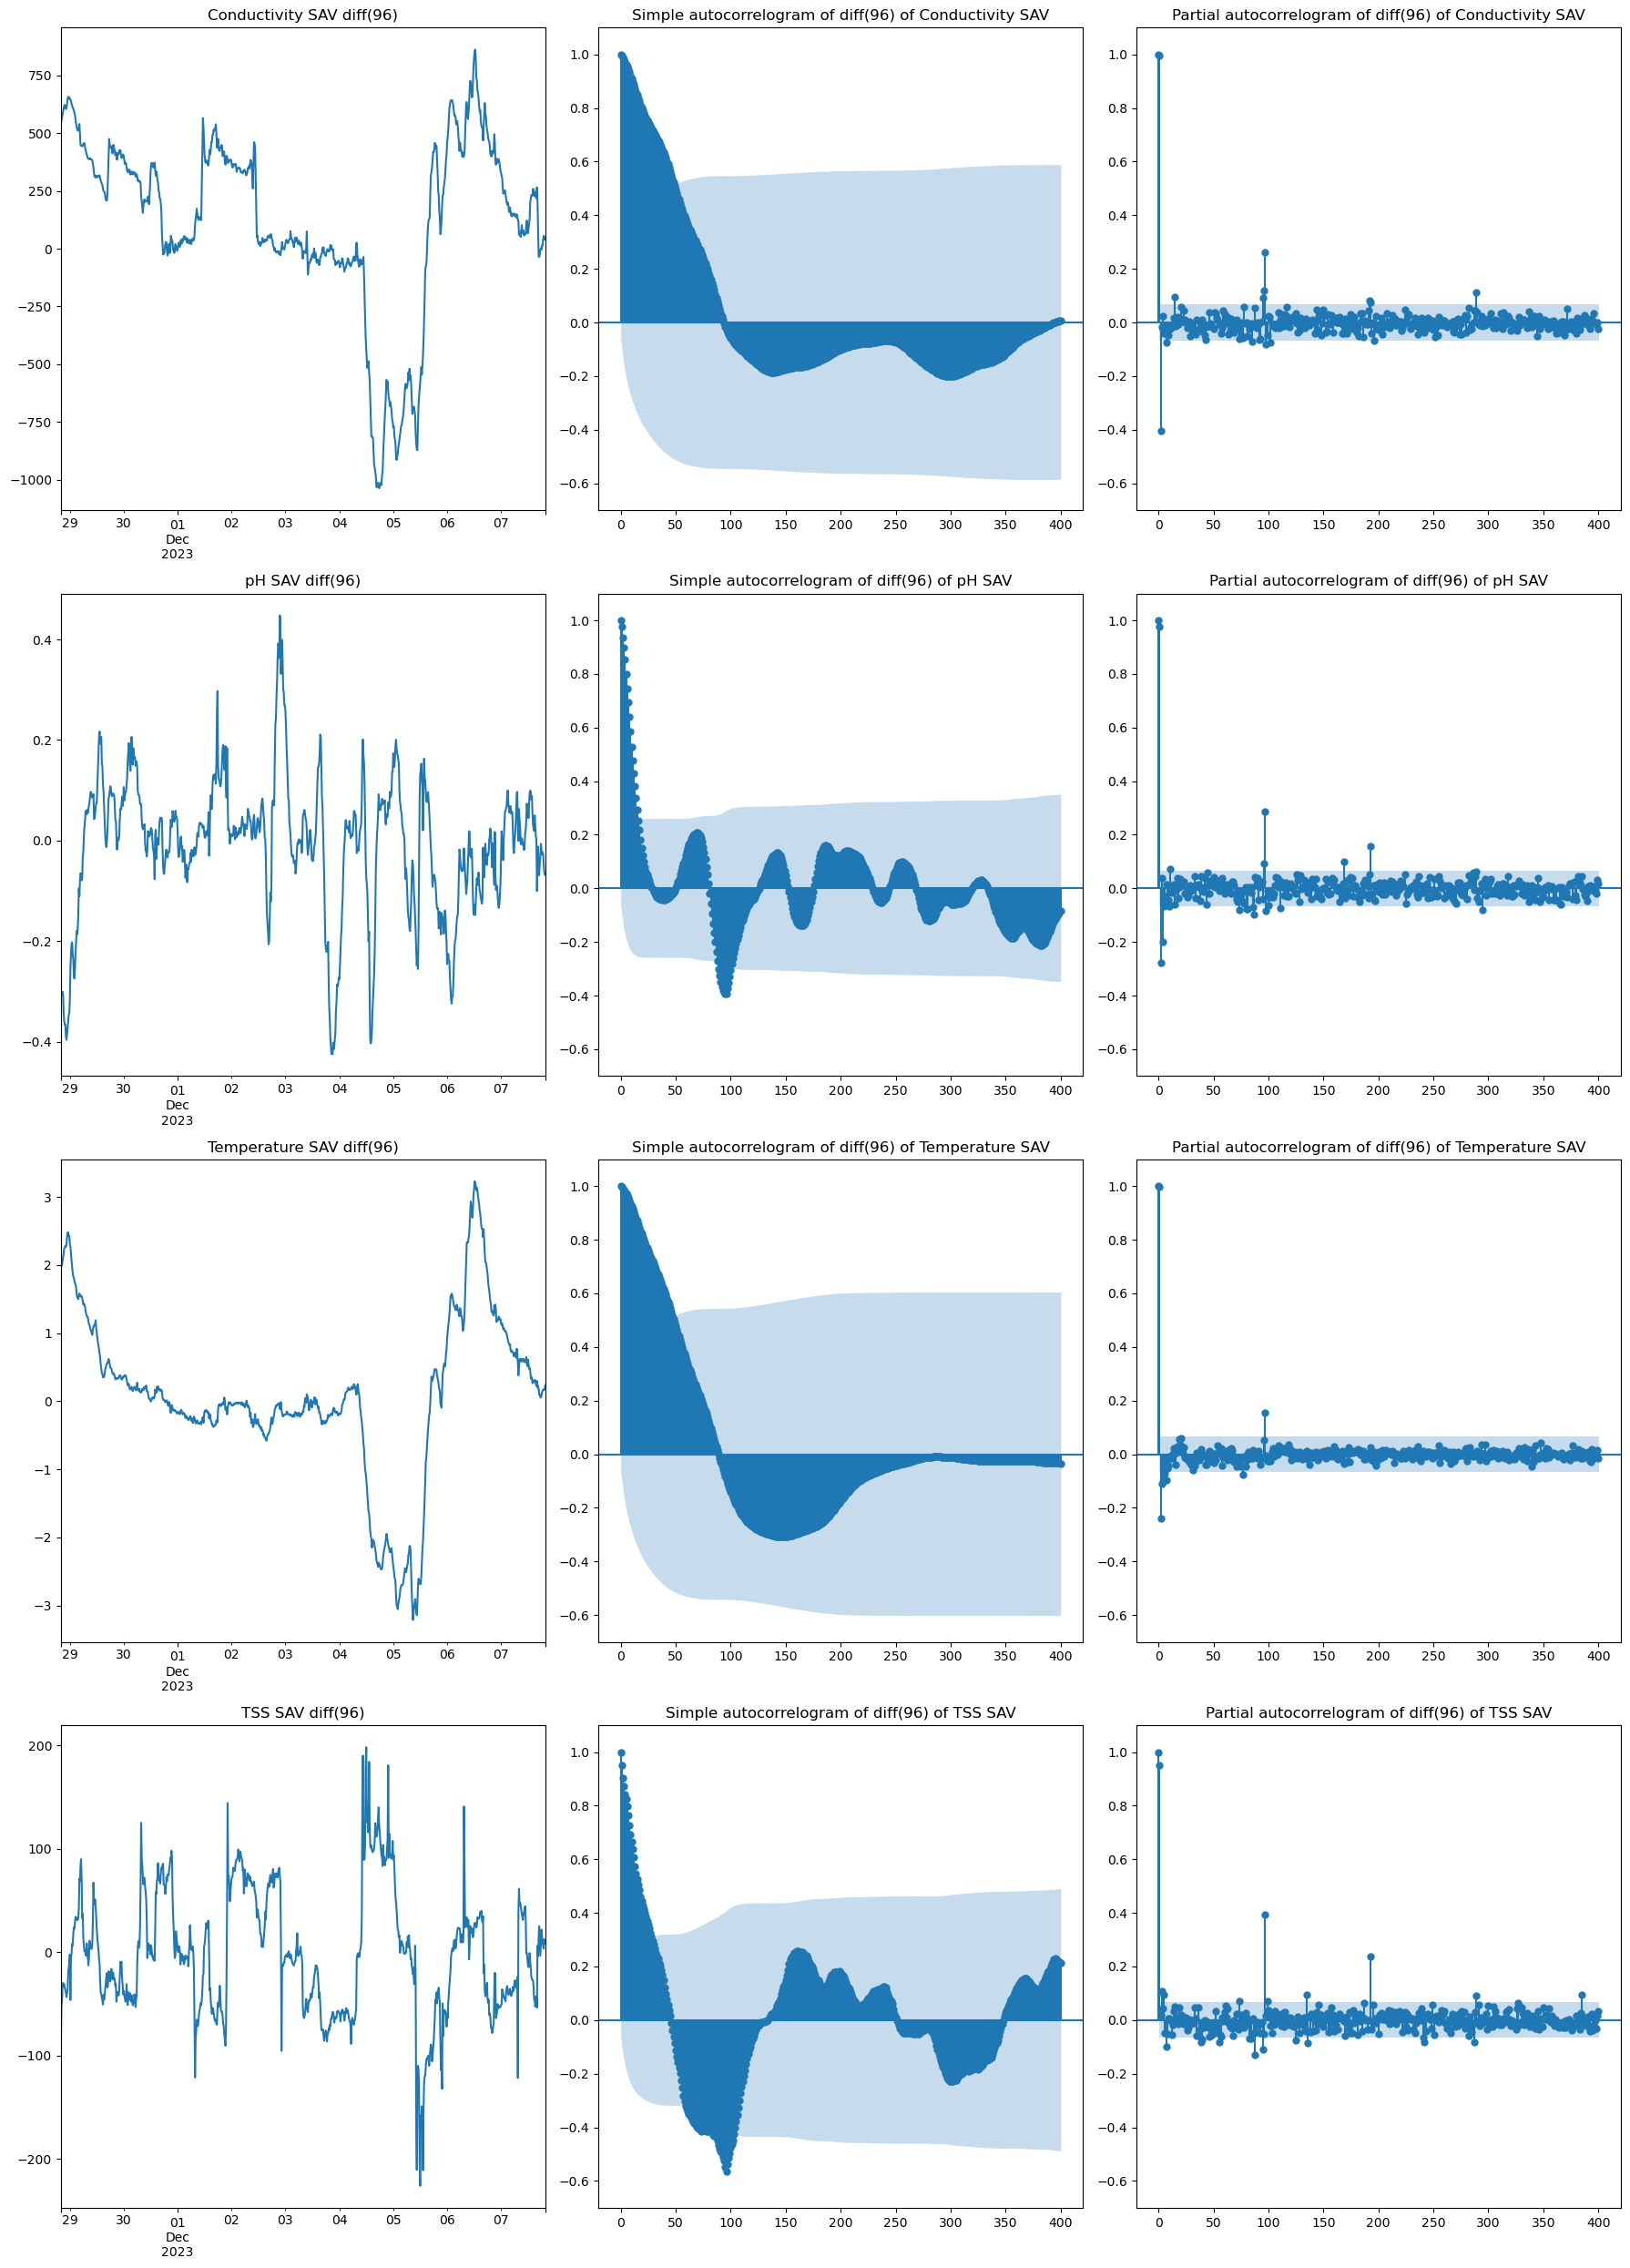

In [4]:
col = df_train.columns.drop("Total flow")
lag = 400
lag1 = 400
fig = plt.figure(figsize = (18, 25))
layout = (len(col), 3)

for j, name in enumerate(col):
    ts1_ax = plt.subplot2grid(layout, (j,0))
    ts2_ax = plt.subplot2grid(layout, (j,1))
    ts3_ax = plt.subplot2grid(layout, (j,2))
    df_train[name].diff(96).dropna().plot(ax = ts1_ax)
    smt.graphics.plot_acf(df_train[name].diff(96).dropna(), lags = lag, ax = ts2_ax)
    smt.graphics.plot_pacf(df_train[name].diff(96).dropna(), lags = lag1, ax = ts3_ax, method = "ywm")
    ts1_ax.set_title(name+' diff(96)')
    ts2_ax.set_title('Simple autocorrelogram of diff(96) of '+name)
    ts2_ax.set_ylim(-0.7, 1.1)
    ts3_ax.set_title('Partial autocorrelogram of diff(96) of '+name)
    ts3_ax.set_ylim(-0.7,1.1)
plt.tight_layout()
plt.show()

**ACF and PACF of the first‑order differences for the 96‑order differenced series that were not stationary**

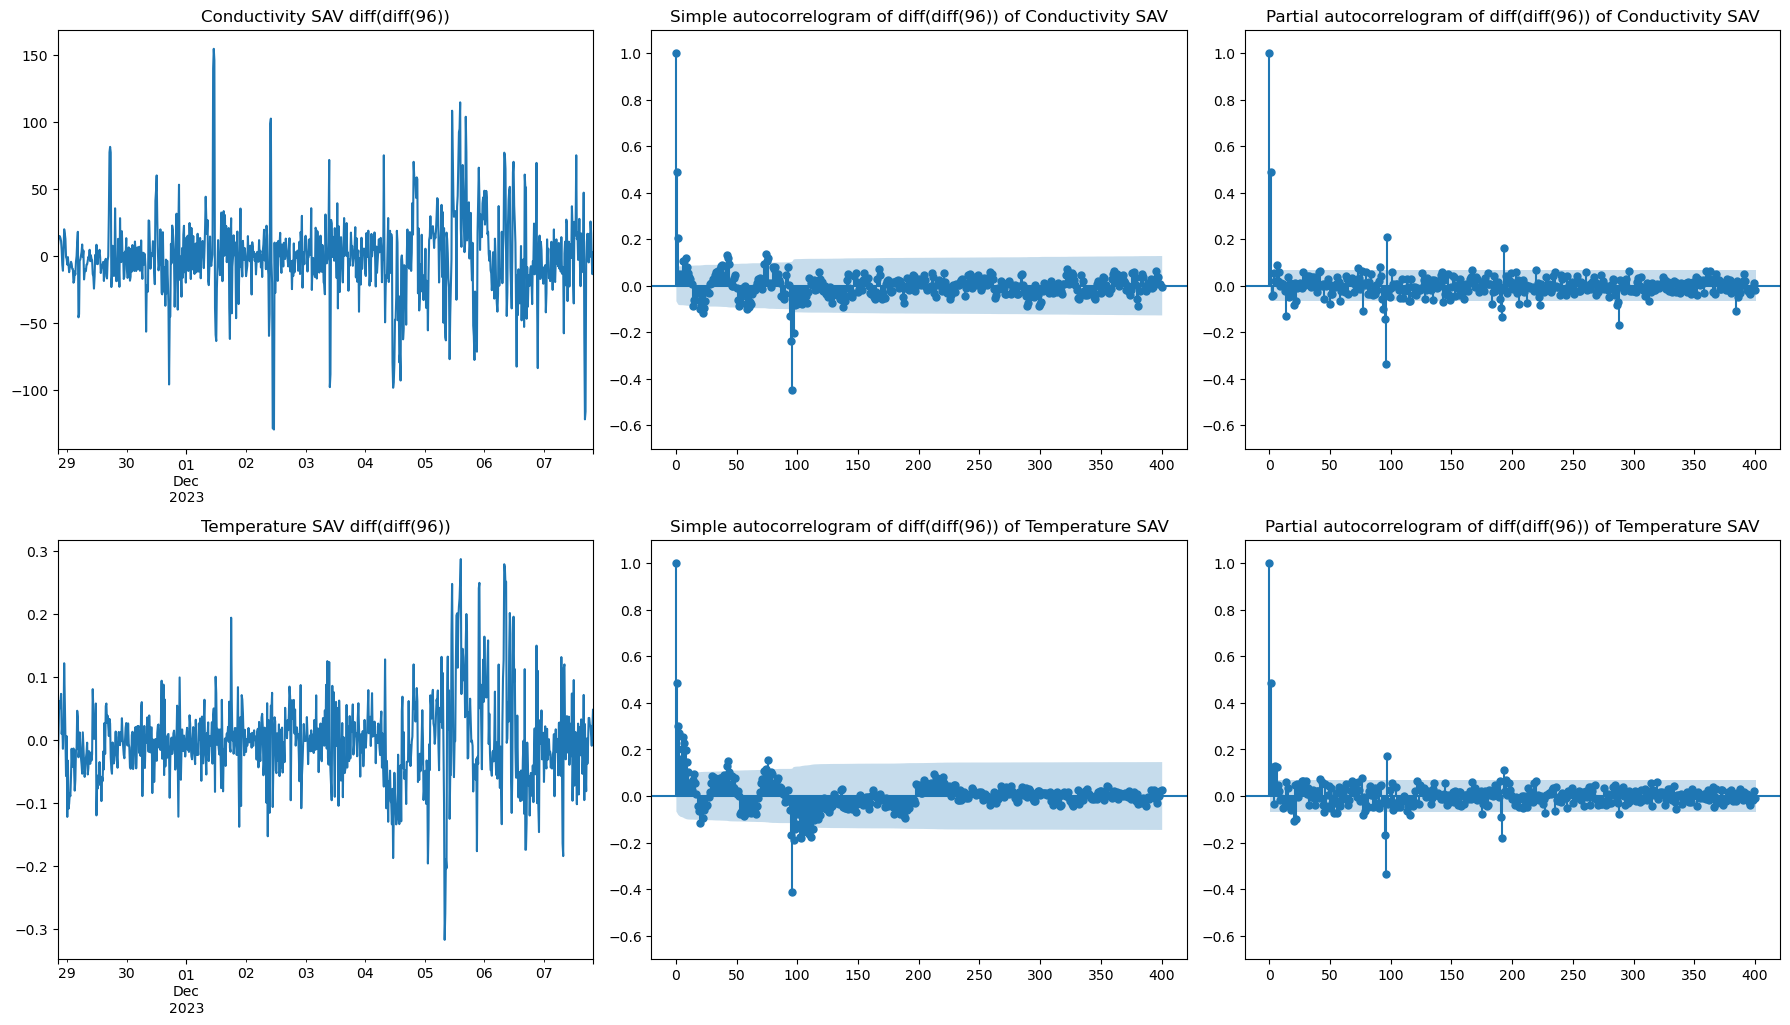

In [12]:
col1 = df_train.columns.drop(['pH SAV', 'TSS SAV', 'Total flow'])
lag = 400
lag1 = 400
fig = plt.figure(figsize = (18, 20))
layout = (len(col), 3)

for j, name in enumerate(col1):
    ts1_ax = plt.subplot2grid(layout, (j,0))
    ts2_ax = plt.subplot2grid(layout, (j,1))
    ts3_ax = plt.subplot2grid(layout, (j,2))
    df_train[name].diff(96).diff().dropna().plot(ax = ts1_ax)
    smt.graphics.plot_acf(df_train[name].diff(96).diff().dropna(), lags = lag, ax = ts2_ax)
    smt.graphics.plot_pacf(df_train[name].diff(96).diff().dropna(), lags = lag1, ax = ts3_ax, method = "ywm")
    ts1_ax.set_title(name+' diff(diff(96))')
    ts2_ax.set_title('Simple autocorrelogram of diff(diff(96)) of '+name)
    ts2_ax.set_ylim(-0.7, 1.1)
    ts3_ax.set_title('Partial autocorrelogram of diff(diff(96)) of '+name)
    ts3_ax.set_ylim(-0.7,1.1)
plt.tight_layout()
plt.show()

In view of the previous tests, the following choices are retained:
* $s = 96$ for all variables,
* $D = 1$ for all variables,
  
* $d = 0$ for all variables, although strictly speaking $d=1$ would apply only to *"Conductivity SAV"* and *"Temperature SAV"*.
* Finally:
  |Variables | $p_{max}$ | $q_{max}$ | $P_{max}$ | $Q_{max}$ |
  |----------|---------|---------|---------|---------|
  |Conductivity SAV |  1 |    2   |     2    |     2     | 
  |pH SAV |   2 |     1   |    2     |    2      |
  |Temperature SAV |  3 |     2   |     2    |     2     |
  |TSS SAV |  2 |     1   |    2     |    2      |

# Forecasting and Evaluation

## All possible models

The code in this section takes a long time to run.  

**For executable files, refer to the "Execution_all_models" folder.** 

The results are saved in .csv files located in the "All_models" folder.

## Analysis of the results and selection of the best models
### Conductivity

In [44]:
Condu_sarima = pd.read_csv("All_models/Condu_sarima.csv", index_col = 0)
Condu_sarima_filtered = filtered_models(Condu_sarima)

# Models selected after filtering
choice(Condu_sarima_filtered)

AIC choice: Index(['(1,1,1)-(0,1,1,96)'], dtype='object', name='Modèle')
BIC choice: Index(['(1,1,1)-(0,1,1,96)'], dtype='object', name='Modèle')
HQIC choice: Index(['(1,1,1)-(0,1,1,96)'], dtype='object', name='Modèle')
Log-Vraisemblance choice: Index(['(1,1,1)-(0,1,1,96)'], dtype='object', name='Modèle')


In [45]:
# Best model: after testing all selected models, this one was chosen
model_condu = sm.tsa.statespace.SARIMAX(df_train['Conductivity SAV'],
                                      order = (1, 1, 1),
                                      seasonal_order = (0, 1, 1, 96),
                                      enforce_stationarity = True,
                                      enforce_invertibility = True)
results_condu = model_condu.fit()
results_condu.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                   Conductivity SAV   No. Observations:                  960
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 96)   Log Likelihood               -3850.057
Date:                            Fri, 11 Sep 2026   AIC                           7708.114
Time:                                    16:16:51   BIC                           7727.156
Sample:                                11-27-2023   HQIC                          7715.403
                                     - 12-07-2023                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3839      0.037     10.338      0.000       0.311       0.457
ma.L1          0.1430      0.046      3.105      0.002       0.053       0.233
ma.S.L96      -0.9814      0.323     -3.038      0.002      -1.615      -0.348
sigma2       345.9634    106.131      3.260      0.001     137.950     553.977
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              1042.66
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               1.62   Skew:                             0.43
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Throughout the rest of this section, the parameters of the trained SARIMA models will be saved in .json files to avoid having to re-estimate them in the near future.**

In [46]:
save_sarima_params(results_condu, "All_models/best_model_condu.json")

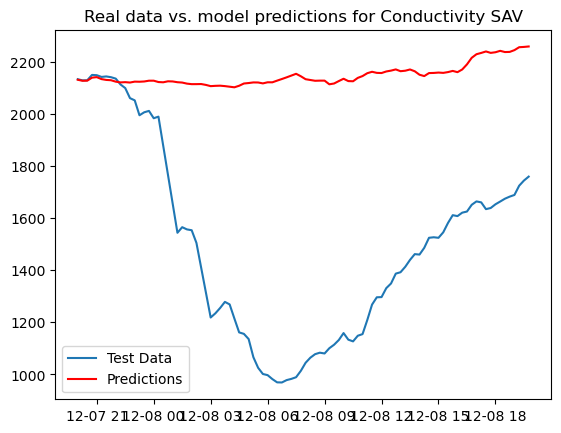

MSE test : 559356.0929373443
MAE test : 656.1956255066767
MAPE test : 52.61133507948998 %


In [15]:
predictions_condu = results_condu.get_forecast(steps = len(df_test_1j['Conductivity SAV']))
plot_predictions(df_test_1j, predictions = predictions_condu, col = 'Conductivity SAV')

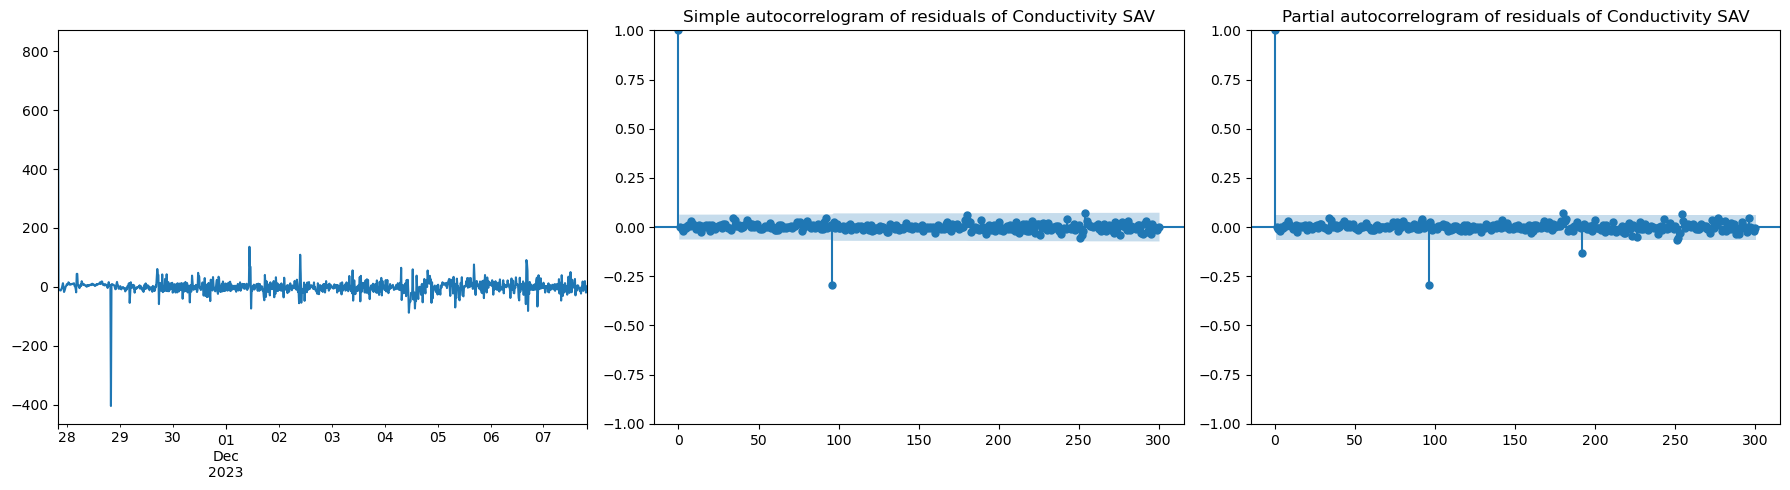

In [22]:
acf_pacf_resid(results_condu, "Conductivity SAV")

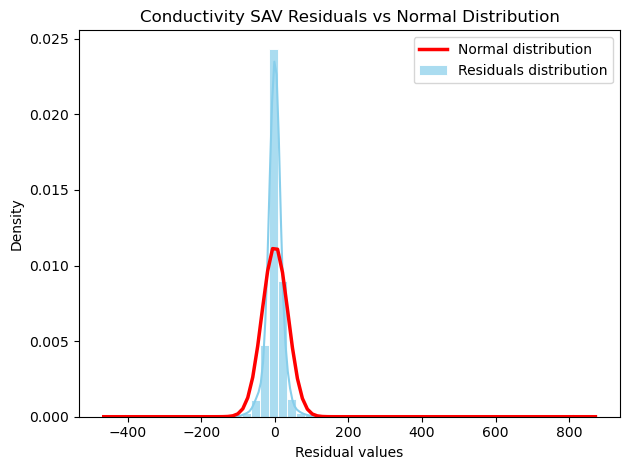

In [5]:
hist_norm(results_condu, "Conductivity SAV")

### pH

In [12]:
ph_sarima = pd.read_csv("All_models/ph_sarima.csv", index_col = 0)
ph_sarima_filtered = filtered_models(ph_sarima)

# Models selected after filtering
choice(ph_sarima_filtered)

AIC choice: Index(['(1,0,1)-(0,1,1,96)'], dtype='object', name='Modèle')
BIC choice: Index(['(1,0,1)-(0,1,1,96)'], dtype='object', name='Modèle')
HQIC choice: Index(['(1,0,1)-(0,1,1,96)'], dtype='object', name='Modèle')
Log-Vraisemblance choice: Index(['(1,0,1)-(0,1,2,96)'], dtype='object', name='Modèle')


In [14]:
model_ph = sm.tsa.statespace.SARIMAX(df_train['pH SAV'],
                                      order = (1,0,1),
                                      seasonal_order = (0, 1, 1, 96),
                                      enforce_stationarity = True,
                                      enforce_invertibility = True)
results_ph = model_ph.fit(maxiter = 100)
results_ph.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                             pH SAV   No. Observations:                  960
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 96)   Log Likelihood                2083.048
Date:                            Fri, 11 Sep 2026   AIC                          -4158.096
Time:                                    14:55:41   BIC                          -4139.050
Sample:                                11-27-2023   HQIC                         -4150.806
                                     - 12-07-2023                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9678      0.007    134.410      0.000       0.954       0.982
ma.L1          0.3771      0.021     18.166      0.000       0.336       0.418
ma.S.L96      -0.9440      0.123     -7.690      0.000      -1.185      -0.703
sigma2         0.0004   4.14e-05      9.247      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.17   Jarque-Bera (JB):              1835.98
Prob(Q):                              0.68   Prob(JB):                         0.00
Heteroskedasticity (H):               1.40   Skew:                            -0.54
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [20]:
save_sarima_params(results_ph, "All_models/best_model_ph.json")

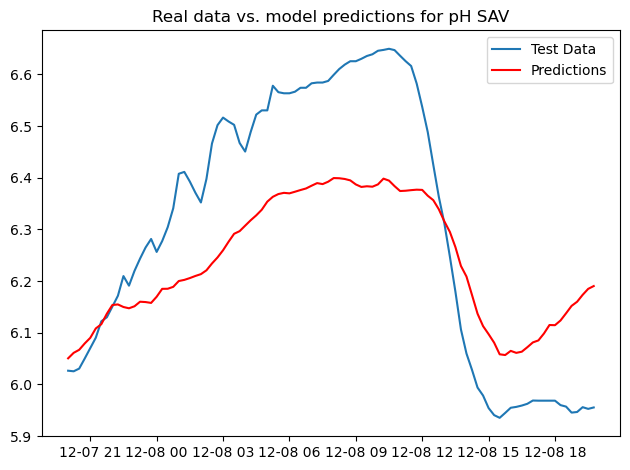

MSE test : 0.028998413507095786
MAE test : 0.15330858587637805
MAPE test : 2.4077276204975 %


In [24]:
predictions_ph = results_ph.get_forecast(steps = len(df_test_1j['pH SAV']))
plot_predictions(df_test_1j, predictions = predictions_ph, col = 'pH SAV')

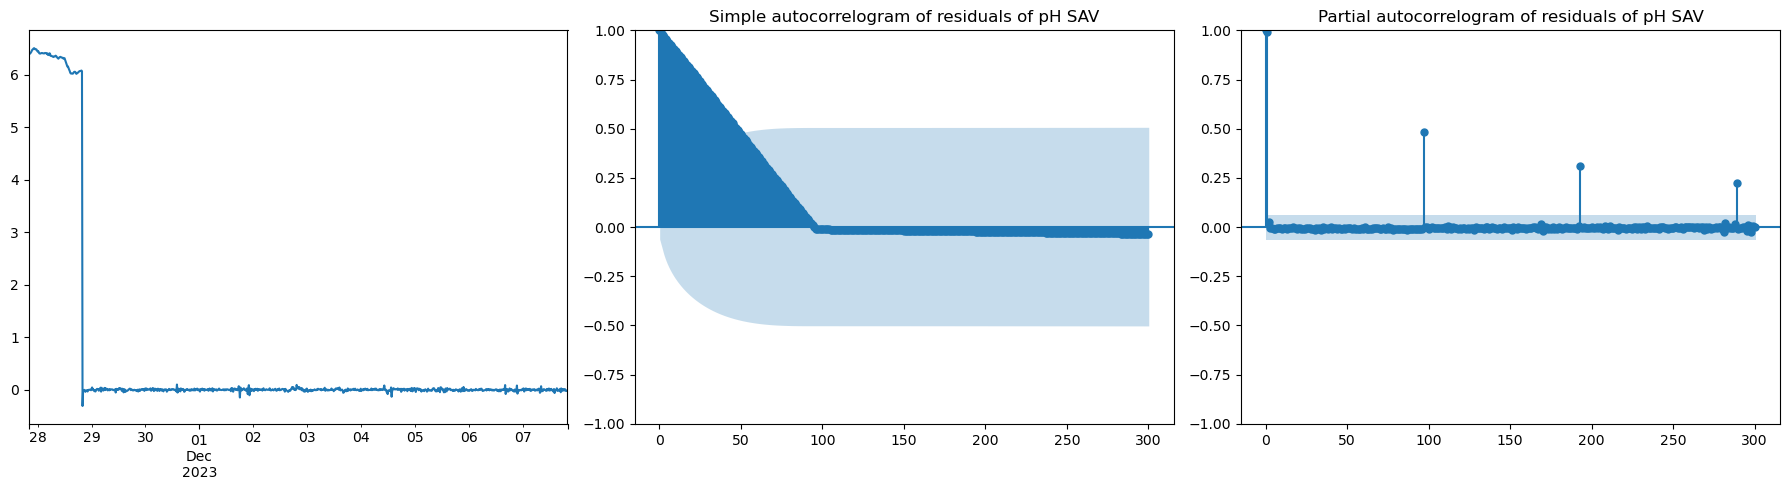

In [26]:
acf_pacf_resid(results_ph, "pH SAV")

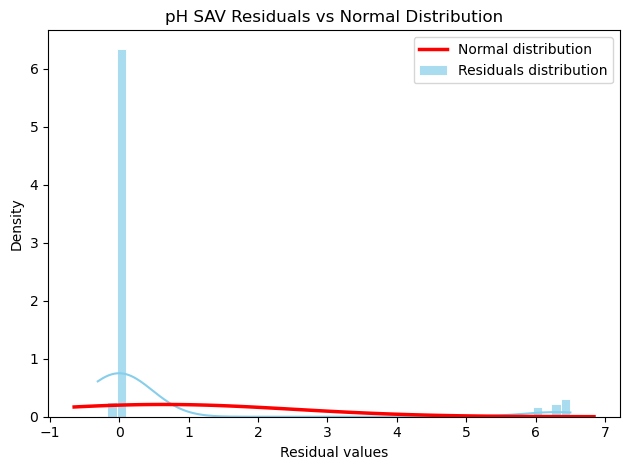

In [27]:
hist_norm(results_ph, "pH SAV")

### Temperature

In [30]:
Temp_sarima = pd.read_csv("All_models/Temp_sarima.csv", index_col = 0)
Temp_sarima_filtered = filtered_models(Temp_sarima)

# Models selected after filtering
choice(Temp_sarima_filtered)

AIC choice: Index(['(2,1,2)-(0,1,1,96)'], dtype='object', name='Modèle')
BIC choice: Index(['(1,1,2)-(0,1,1,96)'], dtype='object', name='Modèle')
HQIC choice: Index(['(2,1,2)-(0,1,1,96)'], dtype='object', name='Modèle')
Log-Vraisemblance choice: Index(['(2,1,2)-(0,1,1,96)'], dtype='object', name='Modèle')


In [34]:
# BIC choice was selected
model_temp = sm.tsa.statespace.SARIMAX(df_train['Temperature SAV'],
                                      order = (1, 1, 2),
                                      seasonal_order = (0, 1, 1, 96),
                                      enforce_stationarity = True,
                                      enforce_invertibility = True)
results_temp = model_temp.fit()
results_temp.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                      Temperature SAV   No. Observations:                  960
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 96)   Log Likelihood                1421.809
Date:                              Fri, 11 Sep 2026   AIC                          -2833.618
Time:                                      16:01:21   BIC                          -2809.816
Sample:                                  11-27-2023   HQIC                         -2824.507
                                       - 12-07-2023                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9047      0.022     40.604      0.000       0.861       0.948
ma.L1         -0.4530      0.030    -14.968      0.000      -0.512      -0.394
ma.L2         -0.2041      0.026     -7.738      0.000      -0.256      -0.152
ma.S.L96      -0.9057      0.060    -15.194      0.000      -1.023      -0.789
sigma2         0.0018   9.22e-05     19.762      0.000       0.002       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):               614.39
Prob(Q):                              0.64   Prob(JB):                         0.00
Heteroskedasticity (H):               3.37   Skew:                             0.20
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.11
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [35]:
save_sarima_params(results_temp, "All_models/best_model_temp.json")

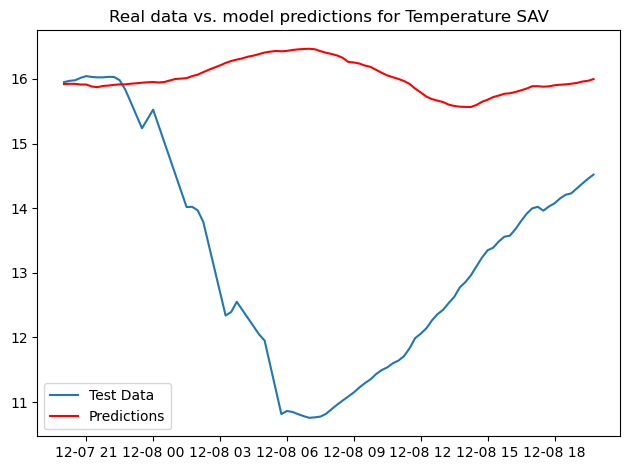

MSE test : 11.226317791777541
MAE test : 2.8267876257186746
MAPE test : 23.48839268429815 %


In [36]:
predictions_temp = results_temp.get_forecast(steps = len(df_test_1j['Temperature SAV']))
plot_predictions(df_test_1j, predictions = predictions_temp, col = 'Temperature SAV')

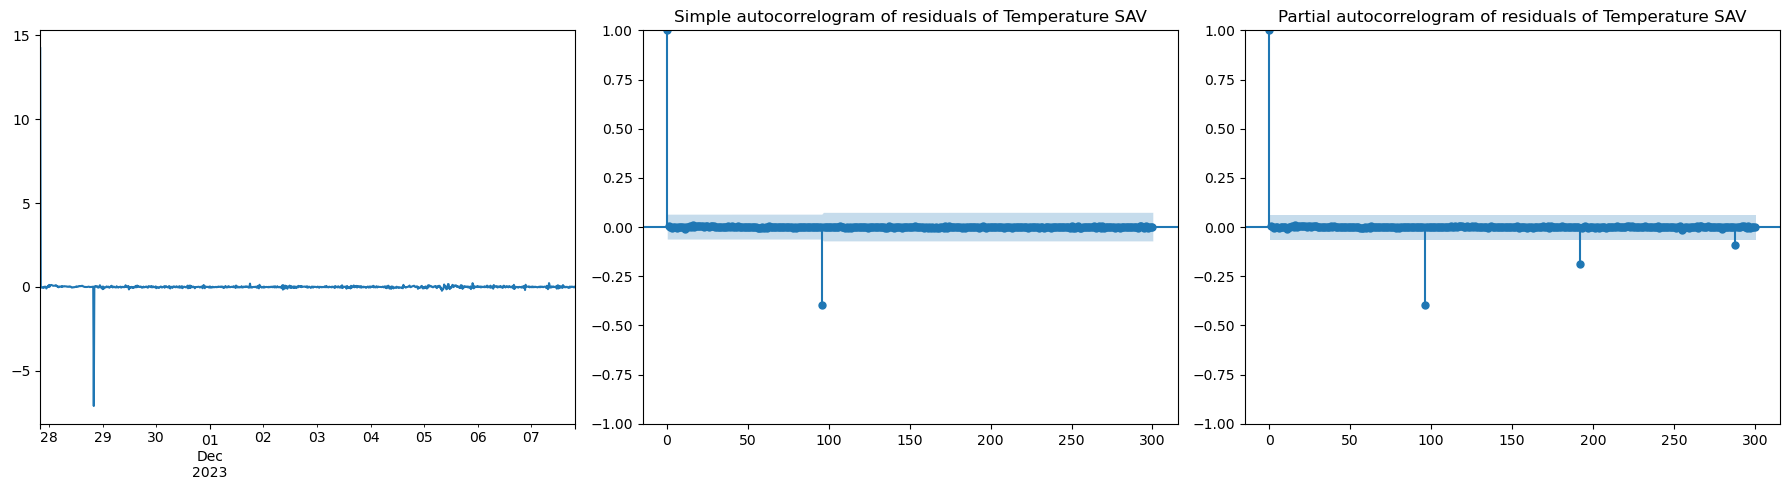

In [37]:
acf_pacf_resid(results_temp, "Temperature SAV")

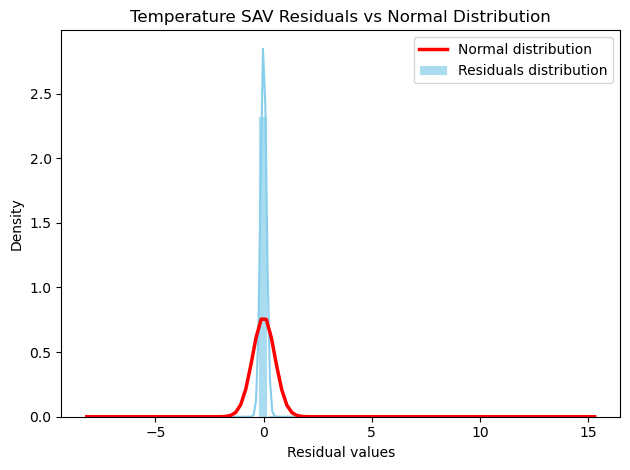

In [38]:
hist_norm(results_temp, "Temperature SAV")

### TSS

In [32]:
tss_sarima = pd.read_csv("All_models/tss_sarima.csv", index_col = 0)
tss_sarima_filtered = filtered_models(tss_sarima)

# Models selected after filtering
choice(tss_sarima_filtered)

AIC choice: Index(['(2,0,1)-(2,1,0,96)'], dtype='object', name='Modèle')
BIC choice: Index(['(1,0,0)-(2,1,0,96)'], dtype='object', name='Modèle')
HQIC choice: Index(['(2,0,1)-(2,1,0,96)'], dtype='object', name='Modèle')
Log-Vraisemblance choice: Index(['(2,0,1)-(2,1,0,96)'], dtype='object', name='Modèle')


In [39]:
# BIC choice was selected
model_tss = sm.tsa.statespace.SARIMAX(df_train['TSS SAV'],
                                      order = (1,0,0),
                                      seasonal_order = (2, 1, 0, 96),
                                      enforce_stationarity = True,
                                      enforce_invertibility = True)
results_tss = model_tss.fit(maxiter = 100)
results_tss.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            TSS SAV   No. Observations:                  960
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 96)   Log Likelihood               -3596.491
Date:                            Fri, 11 Sep 2026   AIC                           7200.981
Time:                                    16:08:28   BIC                           7220.028
Sample:                                11-27-2023   HQIC                          7208.271
                                     - 12-07-2023                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9481      0.007    143.052      0.000       0.935       0.961
ar.S.L96      -0.6794      0.018    -38.509      0.000      -0.714      -0.645
ar.S.L192     -0.3287      0.020    -16.632      0.000      -0.367      -0.290
sigma2       227.0850      3.299     68.841      0.000     220.620     233.550
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):             17550.51
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               2.77   Skew:                             1.67
Prob(H) (two-sided):                  0.00   Kurtosis:                        24.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [40]:
save_sarima_params(results_tss, "All_models/best_model_tss.json")

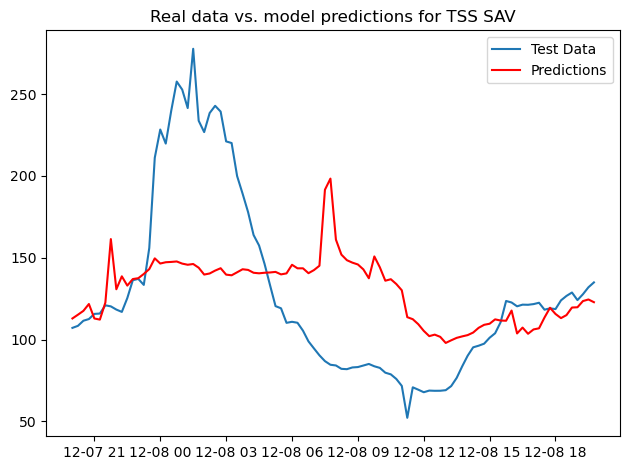

MSE test : 2571.9502275380887
MAE test : 38.29084009537111
MAPE test : 32.679444945287045 %


In [41]:
predictions_tss = results_tss.get_forecast(steps = len(df_test_1j['TSS SAV']))
plot_predictions(df_test_1j, predictions = predictions_tss, col = 'TSS SAV')

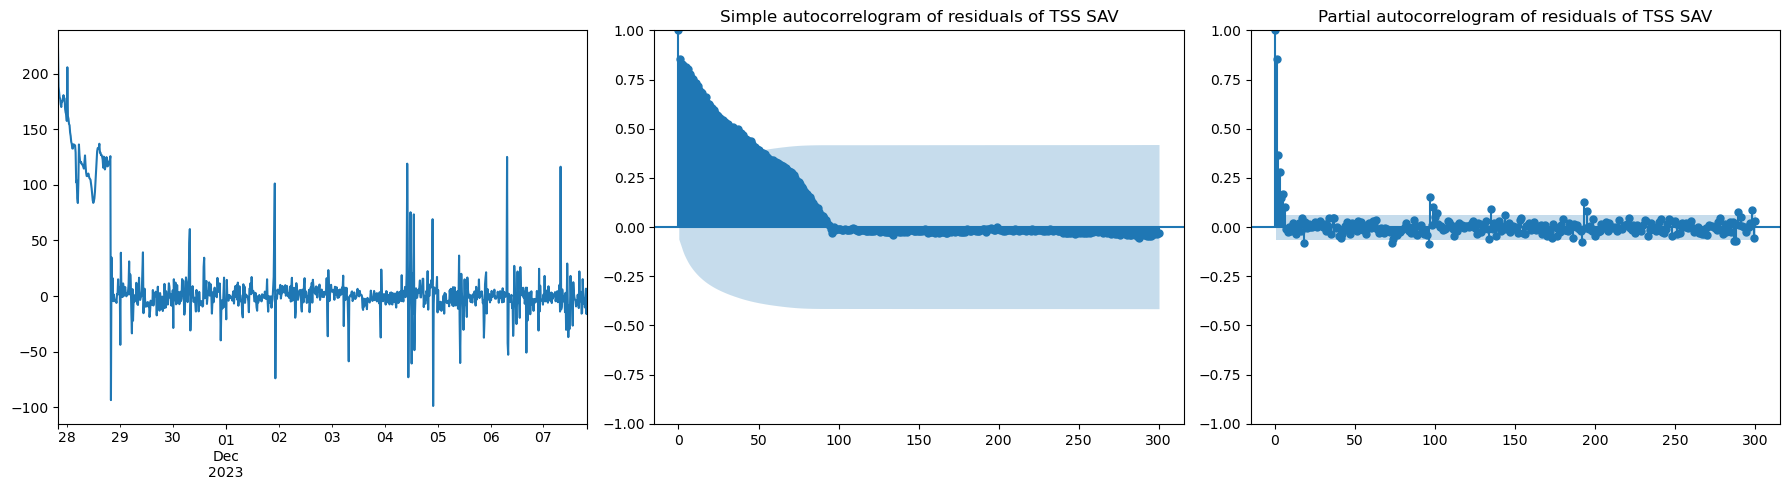

In [42]:
acf_pacf_resid(results_tss, "TSS SAV")

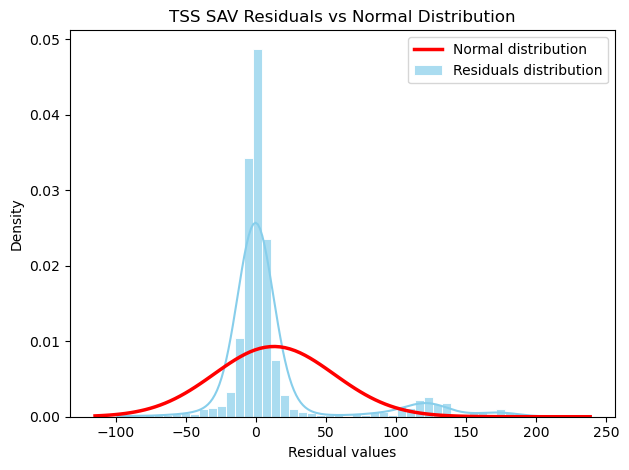

In [43]:
hist_norm(results_tss, "TSS SAV")